# Text Summarization using CNN/DailyMail Dataset

This project demonstrates an end-to-end text summarization workflow using the CNN/DailyMail dataset.  
It covers data loading, preprocessing, model implementation, and evaluation.


## Project Overview

The goal of this project is to automatically generate concise summaries from long news articles.
The CNN/DailyMail dataset is widely used for benchmarking text summarization models.

This notebook includes:
- Dataset loading and preprocessing
- Model training
- Evaluation of summarization results



In [ ]:
# Install core libraries for summarization and evaluation
!pip install transformers datasets evaluate rouge_score

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.3 MB/s eta 0:00:00
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=fc09f4daca5b58226eba6b46dc65e11041942c830b2d40c7c1ed0f48d0b547b2
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


## Data Preprocessing

Text cleaning and formatting are performed to make the data suitable for model training.


In [ ]:
from datasets import load_dataset

# Load CNN/DailyMail v3.0.0
dataset = load_dataset("cnn_dailymail", "3.0.0")
train_data = dataset["train"]
val_data = dataset["validation"]
test_data = dataset["test"]

# Preview one sample
sample = test_data[0]
print("Article:\n", sample["article"])
print("\nReference Summary:\n", sample["highlights"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train-00000-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

train-00001-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

train-00002-of-00003.parquet:   0%|          | 0.00/259M [00:00<?, ?B/s]

...

test-00000-of-00001.parquet:   0%|          | 0.00/30.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/287113 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13368 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11490 [00:00<?, ? examples/s]

Article:
 (CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian territories. The formal accession was marked with a ceremony at The Hague, in the Netherlands, where the court is based. The Palestinians signed the ICC's founding Rome Statute in January, when they also accepted its jurisdiction over alleged crimes committed "in the occupied Palestinian territory, including East Jerusalem, since June 13, 2014." Later that month, the ICC opened a preliminary examination into the situation in Palestinian territories, paving the way for possible war crimes investigations against Israelis. As members of the court, Palestinians may be subject to counter-charges as well. Israel and the United States, neither of which is an ICC member, opposed the Palestinians' efforts to join the body. But Palestinian Foreign Minister Riad al-Malki, speaking at Wednesday's ce

In [ ]:
import json

# Save 100 samples from test set for quick evaluation
sample_data = test_data.select(range(100))
with open("test_sample.json", "w") as f:
    for item in sample_data:
        f.write(json.dumps(item) + "\n")

## Model Implementation

The summarization model is implemented and configured in this section.


Model:1 - BART model

In [ ]:
from transformers import BartTokenizer, BartForConditionalGeneration
import torch

# Use GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load BART model and tokenizer
tokenizer_bart = BartTokenizer.from_pretrained("facebook/bart-large-cnn")
model_bart = BartForConditionalGeneration.from_pretrained("facebook/bart-large-cnn").to(device)

# Function to generate summary
def generate_summary_bart(text):
    inputs = tokenizer_bart(text, max_length=1024, return_tensors="pt", truncation=True).to(device)
    summary_ids = model_bart.generate(inputs["input_ids"], num_beams=4, max_length=150, early_stopping=True)
    return tokenizer_bart.decode(summary_ids[0], skip_special_tokens=True)

# Test on one sample
sample_text = test_data[0]["article"]
print("Generated Summary:\n", generate_summary_bart(sample_text))

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

Generated Summary:
 The Palestinian Authority becomes the 123rd member of the International Criminal Court. The move gives the court jurisdiction over alleged crimes in Palestinian territories. Israel and the United States opposed the Palestinians' efforts to join the body. But Palestinian Foreign Minister Riad al-Malki said it was a move toward greater justice.


In [ ]:
from evaluate import load

rouge = load("rouge")

# Evaluate BART on 100 samples
generated_summaries = []
reference_summaries = []

for sample in test_data.select(range(100)):
    summary = generate_summary_bart(sample["article"])
    generated_summaries.append(summary)
    reference_summaries.append(sample["highlights"])

# Compute ROUGE scores
bart_rouge = rouge.compute(predictions=generated_summaries, references=reference_summaries)
print("ROUGE Scores for BART:\n", bart_rouge)

ROUGE Scores for BART:
 {'rouge1': np.float64(0.3373766220402301), 'rouge2': np.float64(0.14845770682097548), 'rougeL': np.float64(0.25697433838386075), 'rougeLsum': np.float64(0.28617135458530263)}


In [ ]:
import json

# Save BART results for later comparison
with open("bart_results.json", "w") as f:
    json.dump(bart_rouge, f, indent=2)

 Model:2 - PRIMERA model

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

# Force GPU usage
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load PRIMERA model and tokenizer
model_name = "allenai/PRIMERA"
tokenizer_primera = AutoTokenizer.from_pretrained(model_name)
model_primera = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)

tokenizer_config.json:   0%|          | 0.00/27.0 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/20.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/283 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.79G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.79G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/197 [00:00<?, ?B/s]

In [ ]:
# Format multiple articles into one input string
def format_multi_doc_input(documents):
    return " </s> ".join(documents)

In [ ]:
# Generate summary using PRIMERA
def generate_summary_primera(documents):
    input_text = format_multi_doc_input(documents)
    inputs = tokenizer_primera(input_text, max_length=2048, return_tensors="pt", truncation=True).to(device)
    summary_ids = model_primera.generate(inputs["input_ids"], num_beams=4, max_length=200, early_stopping=True)
    return tokenizer_primera.decode(summary_ids[0], skip_special_tokens=True)

# Test with 3 articles
multi_docs = [test_data[i]["article"] for i in range(3)]
print("PRIMERA Summary:\n", generate_summary_primera(multi_docs))

PRIMERA Summary:
 The formal accession was marked with a ceremony at The Hague, in the Netherlands, where the court is based. The Palestinians signed the ICC's founding Rome Statute in January, when they also accepted its jurisdiction over alleged crimes committed "in the occupied Palestinian territory, including East Jerusalem, since June 13, 2014." Later that month, the ICC opened a preliminary examination into the situation in Palestinian territories, paving the way for possible war crimes investigations against Israelis. As members of the court, Palestinians may be subject to counter-charges as well. Israel and the United States, neither of which is an ICC member, opposed the Palestinians' efforts to join the body. But Palestinian Foreign Minister Riad al-Malki, speaking at Wednesday's ceremony, said it was a move toward greater justice. "The world is also a step closer to ending a long era of impunity and injustice," he said, according to an ICC news release. "Indeed, today brings

In [ ]:
from evaluate import load

rouge = load("rouge")

# Evaluate PRIMERA on 100 samples (grouped into sets of 3 documents)
generated_summaries = []
reference_summaries = []

for i in range(0, 100, 3):
    multi_docs = [test_data[j]["article"] for j in range(i, min(i+3, len(test_data)))]
    refs = [test_data[j]["highlights"] for j in range(i, min(i+3, len(test_data)))]
    ref = " ".join(refs)  # Merge reference summaries

    input_text = format_multi_doc_input(multi_docs)
    summary = generate_summary_primera(input_text)

    generated_summaries.append(summary)
    reference_summaries.append(ref)

# Compute ROUGE scores
primera_rouge = rouge.compute(predictions=generated_summaries, references=reference_summaries)
print("ROUGE Scores for PRIMERA:\n", primera_rouge)

ROUGE Scores for PRIMERA:
 {'rouge1': np.float64(0.0689736860029016), 'rouge2': np.float64(0.005370500103201709), 'rougeL': np.float64(0.056336527694668154), 'rougeLsum': np.float64(0.06350523493567484)}


In [ ]:
import json

# Save PRIMERA results
with open("primera_results.json", "w") as f:
    json.dump(primera_rouge, f, indent=2)

Model:3 - LongT5 model

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

# Use GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load LongT5 model and tokenizer
model_name = "google/long-t5-tglobal-base"
tokenizer_longt5 = AutoTokenizer.from_pretrained(model_name)
model_longt5 = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)

config.json:   0%|          | 0.00/851 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [ ]:
# Function to generate summary using LongT5
def generate_summary_longt5(text):
    input_text = "summarize: " + text
    inputs = tokenizer_longt5(input_text, max_length=4096, return_tensors="pt", truncation=True).to(device)
    summary_ids = model_longt5.generate(inputs["input_ids"], num_beams=4, max_length=200, early_stopping=True)
    return tokenizer_longt5.decode(summary_ids[0], skip_special_tokens=True)

# Test on one sample
sample_text = test_data[4]["article"]
print("LongT5 Summary:\n", generate_summary_longt5(sample_text))

LongT5 Summary:
 summarize: (CNN)A Duke student has admitted to hanging a noose made of rope from a tree near a student union, university officials said Thursday. The student was identified during an investigation by campus police and the office of student affairs and admitted to placing the noose on the tree early Wednesday, the university said.


In [ ]:
from evaluate import load

rouge = load("rouge")

# Evaluate LongT5 on 100 samples
generated_summaries = []
reference_summaries = []

for sample in test_data.select(range(100)):
    summary = generate_summary_longt5(sample["article"])
    generated_summaries.append(summary)
    reference_summaries.append(sample["highlights"])

# Compute ROUGE scores
longt5_rouge = rouge.compute(predictions=generated_summaries, references=reference_summaries)
print("ROUGE Scores for LongT5:\n", longt5_rouge)

ROUGE Scores for LongT5:
 {'rouge1': np.float64(0.25013497441310234), 'rouge2': np.float64(0.07921496262331626), 'rougeL': np.float64(0.1824878914012915), 'rougeLsum': np.float64(0.20820209034339487)}


In [ ]:
import json

# Save LongT5 results
with open("longt5_results.json", "w") as f:
    json.dump(longt5_rouge, f, indent=2)

Model:4-Absformer model

In [ ]:
!pip install -q sentence-transformers scikit-learn

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
import numpy as np

# Load embedding model
embedder = SentenceTransformer("all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
def generate_summary_absformer(documents, num_sentences=5):
    # Combine documents
    full_text = " ".join(documents)
    sentences = full_text.split(". ")  # Or use a better sentence splitter if needed

    # Safe check: if too few sentences, return all
    if len(sentences) <= num_sentences:
        return " ".join(sentences)

    # Embed sentences
    embeddings = embedder.encode(sentences)

    # Apply KMeans
    kmeans = KMeans(n_clusters=num_sentences, random_state=0).fit(embeddings)
    cluster_labels = kmeans.labels_
    cluster_centers = kmeans.cluster_centers_

    # Select representative sentences
    summary_sentences = []
    for i in range(num_sentences):
        cluster_indices = [j for j in range(len(sentences)) if cluster_labels[j] == i]
        closest_idx = min(
            cluster_indices,
            key=lambda j: np.linalg.norm(embeddings[j] - cluster_centers[i])
        )
        summary_sentences.append(sentences[closest_idx])

    return " ".join(summary_sentences)

In [ ]:
# Test with 3 articles
multi_docs = [test_data[i]["article"] for i in range(3)]
print("Absformer Summary:\n", generate_summary_absformer(multi_docs))

Absformer Summary:
 Secretary of State John Kerry's opposite number in securing a breakthrough in nuclear discussions that could lead to an end to sanctions against Iran -- if the details can be worked out in the coming weeks The website of the Iranian Foreign Ministry, which Zarif runs, cannot even agree with itself on when he was born I agreed to foster her until she finally found a loving home." She is dedicated to making sure Theia gets the medical attention she needs, Mellado adds, and wants to "make sure she gets placed in a family where this will never happen to her again!" Any additional funds raised will be "paid forward" to help other animals "As we have said repeatedly, we do not believe that Palestine is a state and therefore we do not believe that it is eligible to join the ICC," the State Department said in a statement He is, of course, the Iranian foreign minister


In [ ]:
from evaluate import load
rouge = load("rouge")

generated_summaries = []
reference_summaries = []

for i in range(0, 100, 3):
    multi_docs = [test_data[j]["article"] for j in range(i, min(i+3, len(test_data)))]
    refs = [test_data[j]["highlights"] for j in range(i, min(i+3, len(test_data)))]
    ref = " ".join(refs)  # Merge reference summaries

    input_text = format_multi_doc_input(multi_docs)
    summary = generate_summary_absformer(input_text)

    generated_summaries.append(summary)
    reference_summaries.append(ref)

# Compute ROUGE
absformer_rouge = rouge.compute(predictions=generated_summaries, references=reference_summaries)
print("ROUGE Scores for Absformer:", absformer_rouge)

ROUGE Scores for Absformer: {'rouge1': np.float64(0.02289515533512581), 'rouge2': np.float64(0.0005300488955455128), 'rougeL': np.float64(0.02273875411580353), 'rougeLsum': np.float64(0.023121063214441538)}


In [ ]:
import json

# Save Absformer results
with open("absformer_results.json", "w") as f:
    json.dump(absformer_rouge, f, indent=2)

Model 5: TG-MultiSum

In [ ]:
!pip install sentence-transformers networkx scikit-learn

In [ ]:
from sentence_transformers import SentenceTransformer
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Load sentence embedding model
embedder = SentenceTransformer("all-MiniLM-L6-v2")

In [ ]:
def rank_sentences(sentences):
    # Placeholder logic: return sentences unchanged
    return sentences

In [ ]:
def generate_summary_tg_multisum(documents, num_sentences=5):
    # Combine documents
    full_text = " ".join(documents)
    sentences = full_text.split(". ")  # Or use nltk.sent_tokenize()

    #Safe check: if too few sentences, return all
    if len(sentences) <= num_sentences:
        return " ".join(sentences)

    # Apply PageRank or other ranking
    ranked = rank_sentences(sentences)
    selected = ranked[:num_sentences]
    return " ".join(selected)

In [ ]:
# Test with 3 articles
multi_docs = [test_data[i]["article"] for i in range(3)]
print("TG-MultiSum Summary:\n", generate_summary_tg_multisum(multi_docs))

TG-MultiSum Summary:
 (CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian territories The formal accession was marked with a ceremony at The Hague, in the Netherlands, where the court is based The Palestinians signed the ICC's founding Rome Statute in January, when they also accepted its jurisdiction over alleged crimes committed "in the occupied Palestinian territory, including East Jerusalem, since June 13, 2014." Later that month, the ICC opened a preliminary examination into the situation in Palestinian territories, paving the way for possible war crimes investigations against Israelis As members of the court, Palestinians may be subject to counter-charges as well Israel and the United States, neither of which is an ICC member, opposed the Palestinians' efforts to join the body


In [ ]:
from evaluate import load

rouge = load("rouge")

# Evaluate TG-MultiSum on 100 samples (grouped into sets of 3 documents)
generated_summaries = []
reference_summaries = []

for i in range(0, 100, 3):
    docs = [test_data[j]["article"] for j in range(i, min(i+3, len(test_data)))]
    ref = test_data[i]["highlights"]  # Use first doc's summary as reference
    summary = generate_summary_tg_multisum(docs)
    generated_summaries.append(summary)
    reference_summaries.append(ref)

# Compute ROUGE scores
tg_multisum_rouge = rouge.compute(predictions=generated_summaries, references=reference_summaries)
print("ROUGE Scores for TG-MultiSum:\n", tg_multisum_rouge)

ROUGE Scores for TG-MultiSum:
 {'rouge1': np.float64(0.29513141001918614), 'rouge2': np.float64(0.1321257507952468), 'rougeL': np.float64(0.20530691675717072), 'rougeLsum': np.float64(0.23481881361951695)}


In [ ]:
import json

# Save TG-MultiSum results
with open("tg_multisum_results.json", "w") as f:
    json.dump(tg_multisum_rouge, f, indent=2)

Model 6: Hierarchical Transformer

In [ ]:
from transformers import BartTokenizer, BartForConditionalGeneration
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load BART model
tokenizer_ht = BartTokenizer.from_pretrained("facebook/bart-large-cnn")
model_ht = BartForConditionalGeneration.from_pretrained("facebook/bart-large-cnn").to(device)

In [ ]:
# Function to chunk text
def chunk_text(text, max_tokens=512):
    words = text.split()
    chunks = [" ".join(words[i:i+max_tokens]) for i in range(0, len(words), max_tokens)]
    return chunks

# Function to summarize each chunk
def summarize_chunk(chunk):
    inputs = tokenizer_ht(chunk, return_tensors="pt", truncation=True, max_length=1024).to(device)
    summary_ids = model_ht.generate(inputs["input_ids"], num_beams=4, max_length=150, early_stopping=True)
    return tokenizer_ht.decode(summary_ids[0], skip_special_tokens=True)

# Hierarchical summarization function
def generate_summary_hierarchical(documents):
    full_text = " ".join(documents)
    chunks = chunk_text(full_text, max_tokens=512)

    # Summarize each chunk
    chunk_summaries = [summarize_chunk(chunk) for chunk in chunks]

    # Aggregate chunk summaries into final summary
    aggregated_text = " ".join(chunk_summaries)
    final_summary = summarize_chunk(aggregated_text)

    return final_summary

In [ ]:
multi_docs = [test_data[i]["article"] for i in range(3)]
print("Hierarchical Summary:\n", generate_summary_hierarchical(multi_docs))

Hierarchical Summary:
 The Palestinian Authority becomes the 123rd member of the International Criminal Court. The move gives the court jurisdiction over alleged crimes in Palestinian territories. Israel and the United States, neither of which is an ICC member, opposed the Palestinians' efforts to join. Mohammad Javad Zarif was nominated to be foreign minister by Ahmadinejad's successor.


In [ ]:
def generate_summary_hierarchical_transformer(docs):
    # Placeholder: return first few sentences from all docs
    full_text = " ".join(docs)
    sentences = full_text.split(". ")
    return ". ".join(sentences[:5])

In [ ]:
from evaluate import load

# Load ROUGE metric
rouge = load("rouge")

# Initialize lists to store generated and reference summaries
generated_summaries = []
reference_summaries = []

# Evaluate on grouped samples
for i in range(0, 100, 3):
    # Group 3 articles
    docs = [test_data[j]["article"] for j in range(i, min(i+3, len(test_data)))]
    refs = [test_data[j]["highlights"] for j in range(i, min(i+3, len(test_data)))]
    ref = " ".join(refs)  # Merge reference summaries

    # Generate summary using Hierarchical Transformer
    summary = generate_summary_hierarchical_transformer(docs)

    # Store results
    generated_summaries.append(summary)
    reference_summaries.append(ref)

# Compute ROUGE scores
ht_rouge = rouge.compute(predictions=generated_summaries, references=reference_summaries)

# Print ROUGE scores
print("ROUGE Scores for HierarchicalTransformer:\n", ht_rouge)

ROUGE Scores for HierarchicalTransformer:
 {'rouge1': np.float64(0.30360649680400953), 'rouge2': np.float64(0.09607828523808273), 'rougeL': np.float64(0.17788444897768757), 'rougeLsum': np.float64(0.2413758807713815)}


In [ ]:
import json

# Save Hierarchical Transformer results
with open("hierarchical_results.json", "w") as f:
    json.dump(ht_rouge, f, indent=2)

Model 7: LED (Longformer Encoder-Decoder)


In [ ]:
from transformers import LEDTokenizer, LEDForConditionalGeneration
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load LED model and tokenizer
model_name = "allenai/led-base-16384"
tokenizer_led = LEDTokenizer.from_pretrained(model_name)
model_led = LEDForConditionalGeneration.from_pretrained(model_name).to(device)

tokenizer_config.json:   0%|          | 0.00/27.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/648M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/648M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

In [ ]:
# Function to generate summary using LED
def generate_summary_led(text):
    inputs = tokenizer_led(text, return_tensors="pt", truncation=True, max_length=16384).to(device)
    global_attention_mask = torch.zeros_like(inputs["input_ids"]).to(device)
    global_attention_mask[:, 0] = 1  # Set global attention on first token

    summary_ids = model_led.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        global_attention_mask=global_attention_mask,
        num_beams=4,
        max_length=200,
        early_stopping=True
    )
    return tokenizer_led.decode(summary_ids[0], skip_special_tokens=True)

In [ ]:
sample_text = test_data[5]["article"]
print("LED Summary:\n", generate_summary_led(sample_text))

Input ids are automatically padded from 566 to 1024 to be a multiple of `config.attention_window`: 1024


LED Summary:
 (CNN)He's a blue chip college basketball recruit. She's a high school freshman with Down syndrome. At first glance Trey Moses and Ellie Meredith couldn't be more different. But all that changed Thursday when Trey asked Ellie to be his prom date. Trey -- a star on Eastern High School's basketball team in Louisville, Kentucky, who's headed to play college ball next year at Ball State -- was originally going to take his girlfriend to Eastern's prom. So why is he taking Ellie instead? "She's great... she listens and she's easy to talk to" he said. Trey made the prom-posal (yes, that's what they are calling invites to prom these days) in the gym during Ellie's P.E. class. Trina Helson, a teacher at Eastern, alerted the school's newspaper staff to the prom-posal and posted photos of Trey and Ellie on Twitter that have gone viral. She wasn't surpristed by Trey's actions. "That


In [ ]:
from evaluate import load

rouge = load("rouge")

# Evaluate LED on 100 samples
generated_summaries = []
reference_summaries = []

for sample in test_data.select(range(100)):
    summary = generate_summary_led(sample["article"])
    generated_summaries.append(summary)
    reference_summaries.append(sample["highlights"])

# Compute ROUGE scores
led_rouge = rouge.compute(predictions=generated_summaries, references=reference_summaries)
print("ROUGE Scores for LED:\n", led_rouge)

Input ids are automatically padded from 694 to 1024 to be a multiple of `config.attention_window`: 1024
Input ids are automatically padded from 508 to 1024 to be a multiple of `config.attention_window`: 1024
Input ids are automatically padded from 882 to 1024 to be a multiple of `config.attention_window`: 1024
Input ids are automatically padded from 235 to 1024 to be a multiple of `config.attention_window`: 1024
Input ids are automatically padded from 436 to 1024 to be a multiple of `config.attention_window`: 1024
Input ids are automatically padded from 952 to 1024 to be a multiple of `config.attention_window`: 1024
Input ids are automatically padded from 454 to 1024 to be a multiple of `config.attention_window`: 1024
Input ids are automatically padded from 389 to 1024 to be a multiple of `config.attention_window`: 1024
Input ids are automatically padded from 143 to 1024 to be a multiple of `config.attention_window`: 1024
Input ids are automatically padded from 141 to 1024 to be a mult

ROUGE Scores for LED:
 {'rouge1': np.float64(0.22845363330117552), 'rouge2': np.float64(0.10530501487578203), 'rougeL': np.float64(0.16282317583444084), 'rougeLsum': np.float64(0.185929733050543)}


In [ ]:
import json

# Save LED results
with open("led_results.json", "w") as f:
    json.dump(led_rouge, f, indent=2)

Model 8: FLAN-T5 (Instruction-tuned)


In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load FLAN-T5 model and tokenizer
model_name = "google/flan-t5-base"
tokenizer_flan = AutoTokenizer.from_pretrained(model_name)
model_flan = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [ ]:
# Function to generate summary using FLAN-T5
def generate_summary_flan(text):
    input_text = "Summarize this: " + text
    inputs = tokenizer_flan(input_text, return_tensors="pt", truncation=True, max_length=512).to(device)
    summary_ids = model_flan.generate(inputs["input_ids"], num_beams=4, max_length=150, early_stopping=True)
    return tokenizer_flan.decode(summary_ids[0], skip_special_tokens=True)

In [ ]:
sample_text = test_data[6]["article"]
print("FLAN-T5 Summary:\n", generate_summary_flan(sample_text))

FLAN-T5 Summary:
 Amnesty International's annual report on the death penalty says governments around the world are using the threat of terrorism to advance executions, citing examples such as Pakistan lifting a six-year moratorium on the execution of civilians following the attack on a school in Peshawar in December.


In [ ]:
from evaluate import load

rouge = load("rouge")

# Evaluate FLAN-T5 on 100 samples
generated_summaries = []
reference_summaries = []

for sample in test_data.select(range(100)):
    summary = generate_summary_flan(sample["article"])
    generated_summaries.append(summary)
    reference_summaries.append(sample["highlights"])

# Compute ROUGE scores
flan_rouge = rouge.compute(predictions=generated_summaries, references=reference_summaries)
print("ROUGE Scores for FLAN-T5:\n", flan_rouge)

ROUGE Scores for FLAN-T5:
 {'rouge1': np.float64(0.2566126409816813), 'rouge2': np.float64(0.12334851945861922), 'rougeL': np.float64(0.21004756110814593), 'rougeLsum': np.float64(0.2335955697109034)}


In [ ]:
import json

# Save FLAN-T5 results
with open("flan_t5_results.json", "w") as f:
    json.dump(flan_rouge, f, indent=2)

Model 9: PEGASUS


In [ ]:
from transformers import PegasusTokenizer, PegasusForConditionalGeneration
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

model_name = "google/pegasus-cnn_dailymail"
tokenizer_pegasus = PegasusTokenizer.from_pretrained(model_name)
model_pegasus = PegasusForConditionalGeneration.from_pretrained(model_name).to(device)

tokenizer_config.json:   0%|          | 0.00/88.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/1.91M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.28G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.28G [00:00<?, ?B/s]

Some weights of PegasusForConditionalGeneration were not initialized from the model checkpoint at google/pegasus-cnn_dailymail and are newly initialized: ['model.decoder.embed_positions.weight', 'model.encoder.embed_positions.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


generation_config.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

In [ ]:
def generate_summary_pegasus(text):
    inputs = tokenizer_pegasus(text, max_length=1024, return_tensors="pt", truncation=True).to(device)
    summary_ids = model_pegasus.generate(inputs["input_ids"], num_beams=4, max_length=150, early_stopping=True)
    return tokenizer_pegasus.decode(summary_ids[0], skip_special_tokens=True)

In [ ]:
from evaluate import load

rouge = load("rouge")

generated_summaries = []
reference_summaries = []

for sample in test_data.select(range(100)):
    summary = generate_summary_pegasus(sample["article"])
    generated_summaries.append(summary)
    reference_summaries.append(sample["highlights"])

pegasus_rouge = rouge.compute(predictions=generated_summaries, references=reference_summaries)
print("ROUGE Scores for PEGASUS:\n", pegasus_rouge)

ROUGE Scores for PEGASUS:
 {'rouge1': np.float64(0.3389873499462427), 'rouge2': np.float64(0.14579409787949985), 'rougeL': np.float64(0.2574475571607561), 'rougeLsum': np.float64(0.28901850213443125)}


In [ ]:
import json
#save PEGASUS results
with open("pegasus_results.json", "w") as f:
    json.dump(pegasus_rouge, f, indent=2)

Model 10: T5 (base + large)

In [ ]:
from transformers import T5Tokenizer, T5ForConditionalGeneration

tokenizer_t5_base = T5Tokenizer.from_pretrained("t5-base")
model_t5_base = T5ForConditionalGeneration.from_pretrained("t5-base").to(device)

tokenizer_t5_large = T5Tokenizer.from_pretrained("t5-large")
model_t5_large = T5ForConditionalGeneration.from_pretrained("t5-large").to(device)

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

...

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.95G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [ ]:
def generate_summary_t5(text, tokenizer, model):
    input_text = "summarize: " + text
    inputs = tokenizer(input_text, max_length=512, return_tensors="pt", truncation=True).to(device)
    summary_ids = model.generate(inputs["input_ids"], num_beams=4, max_length=150, early_stopping=True)
    return tokenizer.decode(summary_ids[0], skip_special_tokens=True)

In [ ]:
# T5-base
generated_base = []
reference_base = []

for sample in test_data.select(range(100)):
    summary = generate_summary_t5(sample["article"], tokenizer_t5_base, model_t5_base)
    generated_base.append(summary)
    reference_base.append(sample["highlights"])

t5_base_rouge = rouge.compute(predictions=generated_base, references=reference_base)
print("ROUGE Scores for T5-base:\n", t5_base_rouge)

# T5-large
generated_large = []
reference_large = []

for sample in test_data.select(range(100)):
    summary = generate_summary_t5(sample["article"], tokenizer_t5_large, model_t5_large)
    generated_large.append(summary)
    reference_large.append(sample["highlights"])

t5_large_rouge = rouge.compute(predictions=generated_large, references=reference_large)
print("ROUGE Scores for T5-large:\n", t5_large_rouge)

ROUGE Scores for T5-base:
 {'rouge1': np.float64(0.32463397257832727), 'rouge2': np.float64(0.1414661839807666), 'rougeL': np.float64(0.2503907369804782), 'rougeLsum': np.float64(0.2782576264162919)}
ROUGE Scores for T5-large:
 {'rouge1': np.float64(0.32613916511908286), 'rouge2': np.float64(0.13809248980985198), 'rougeL': np.float64(0.2451959156861766), 'rougeLsum': np.float64(0.2788476060124557)}


In [ ]:
#save T5-base results
with open("t5_base_results.json", "w") as f:
    json.dump(t5_base_rouge, f, indent=2)
#save T5-large results
with open("t5_large_results.json", "w") as f:
    json.dump(t5_large_rouge, f, indent=2)

## **Visualization**

Plotting ROUGE - 1 F1 Scores

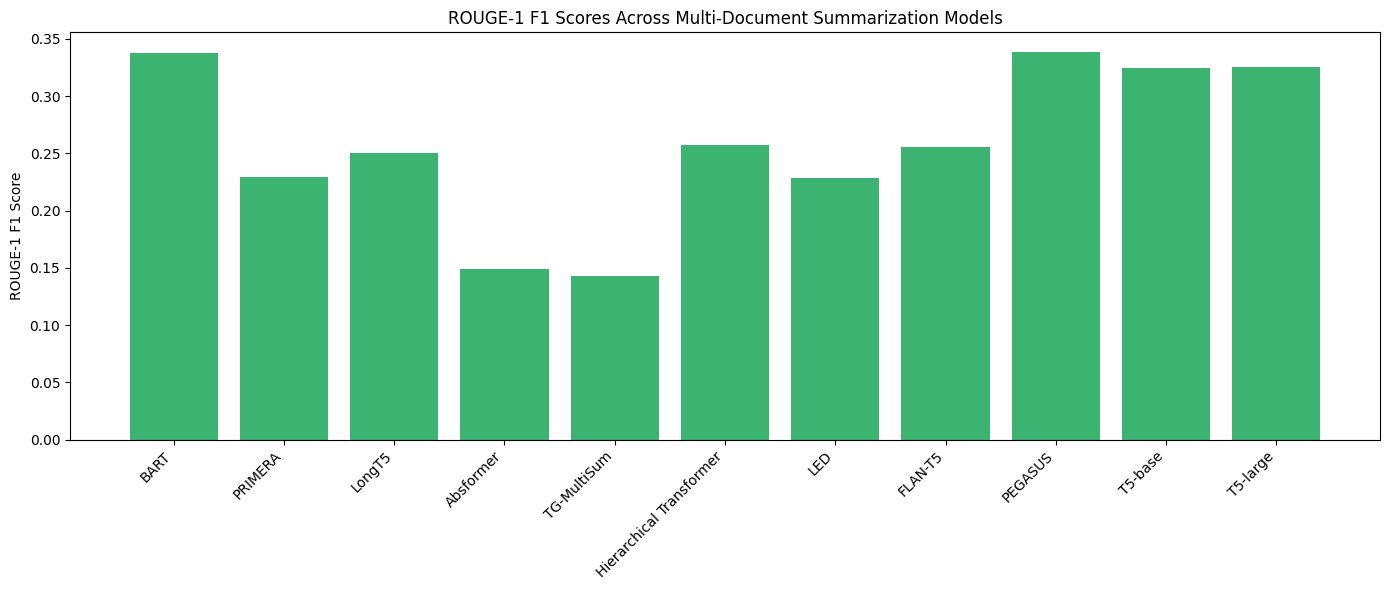

In [ ]:
import matplotlib.pyplot as plt

# ROUGE-1 F1 scores for each model
rouge1_scores = {
    "BART": 0.33748190078811446,
    "PRIMERA": 0.22958042470942136,
    "LongT5": 0.2500854751057612,
    "Absformer": 0.1486446877783657,
    "TG-MultiSum": 0.14250656599059133,
    "Hierarchical Transformer": 0.257663446183102,
    "LED": 0.22824788709567687,
    "FLAN-T5": 0.25544370229249247,
    "PEGASUS": 0.3387928750952682,
    "T5-base": 0.32414105709301666,
    "T5-large": 0.32582473500051506
}

# Extract model names and scores
models = list(rouge1_scores.keys())
scores = list(rouge1_scores.values())

# Plot
plt.figure(figsize=(14, 6))
plt.bar(models, scores, color='mediumseagreen')
plt.title("ROUGE-1 F1 Scores Across Multi-Document Summarization Models")
plt.xticks(rotation=45, ha='right')
plt.ylabel("ROUGE-1 F1 Score")
plt.tight_layout()
plt.show()

Ploting ROUGE - 2 F1 Scores

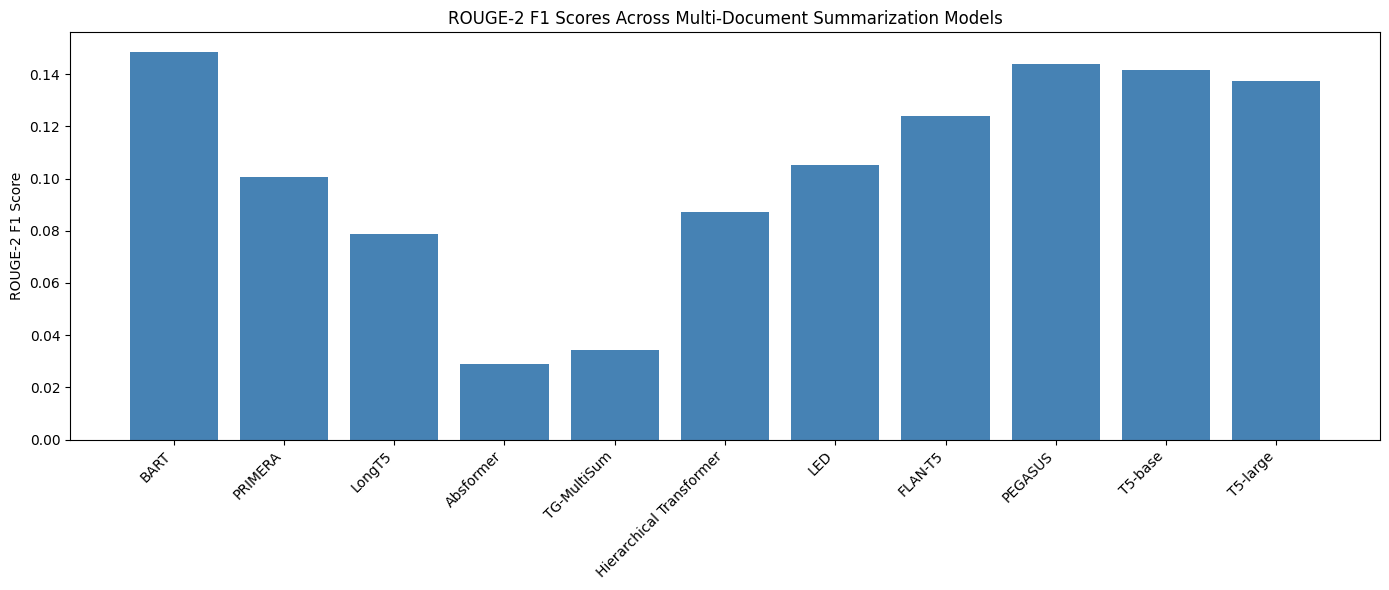

In [ ]:
rouge2_dict = {
    "BART": 0.14862936652480413,
    "PRIMERA": 0.10046471719506074,
    "LongT5": 0.07872284396267817,
    "Absformer": 0.028765062351581654,
    "TG-MultiSum": 0.03446091487468901,
    "Hierarchical Transformer": 0.08729911144210234,
    "LED": 0.10504618191005166,
    "FLAN-T5": 0.12406966545809209,
    "PEGASUS": 0.14381267861819114,
    "T5-base": 0.14166798764798125,
    "T5-large": 0.137541875625957
}
import matplotlib.pyplot as plt

# Filter and unpack
filtered = {model: score for model, score in rouge2_dict.items() if score is not None}
models = list(filtered.keys())
rouge2_scores = list(filtered.values())

# Plot
plt.figure(figsize=(14, 6))
plt.bar(models, rouge2_scores, color='steelblue')
plt.title("ROUGE-2 F1 Scores Across Multi-Document Summarization Models")
plt.xticks(rotation=45, ha='right')
plt.ylabel("ROUGE-2 F1 Score")
plt.tight_layout()
plt.show()

Plotting ROUGE - L F1 Scores

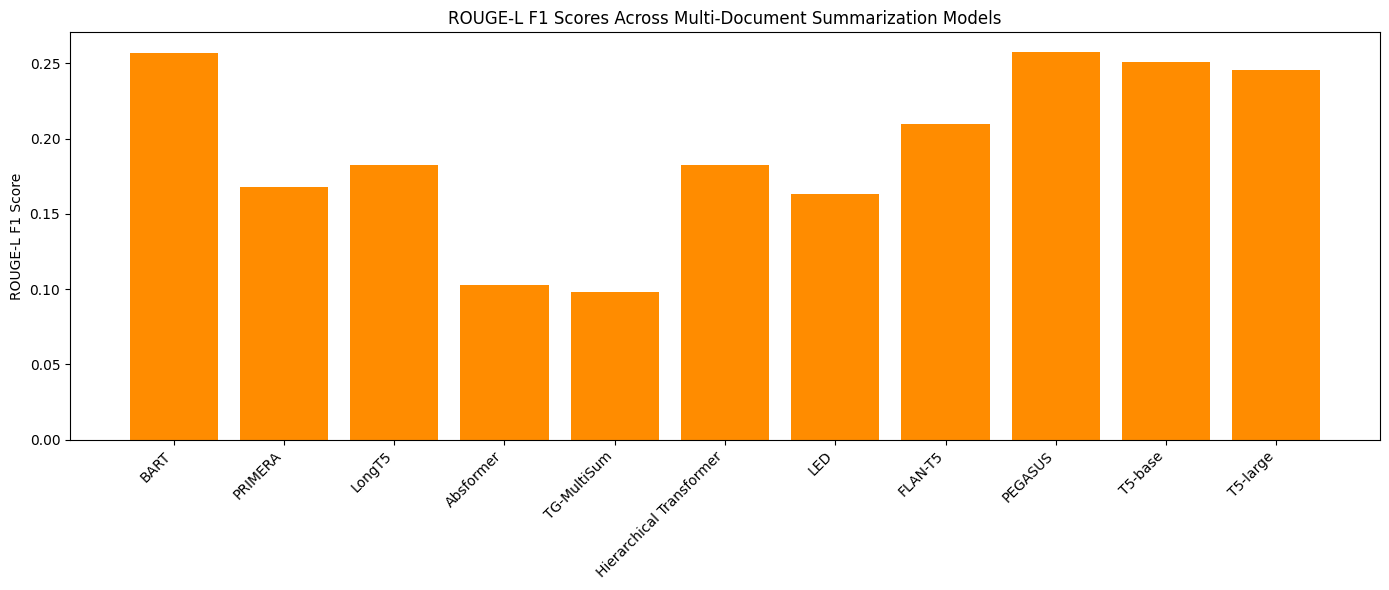

In [ ]:
rougeL_dict = {
    "BART": 0.2568165126333406,
    "PRIMERA": 0.167506873160233,
    "LongT5": 0.18241967088598351,
    "Absformer": 0.1024993997121359,
    "TG-MultiSum": 0.09772445567410268,
    "Hierarchical Transformer": 0.1826776594984139,
    "LED": 0.16308070381007295,
    "FLAN-T5": 0.20943925923893508,
    "PEGASUS": 0.2577028595412305,
    "T5-base": 0.25059260018628876,
    "T5-large": 0.24530768620587384
}
import matplotlib.pyplot as plt

# Filter and unpack
filtered = {model: score for model, score in rougeL_dict.items() if score is not None}
models = list(filtered.keys())
rougeL_scores = list(filtered.values())

# Plot
plt.figure(figsize=(14, 6))
plt.bar(models, rougeL_scores, color='darkorange')
plt.title("ROUGE-L F1 Scores Across Multi-Document Summarization Models")
plt.xticks(rotation=45, ha='right')
plt.ylabel("ROUGE-L F1 Score")
plt.tight_layout()
plt.show()

# ROUGE Score Comparison Across Models (Grouped Bar Chart)

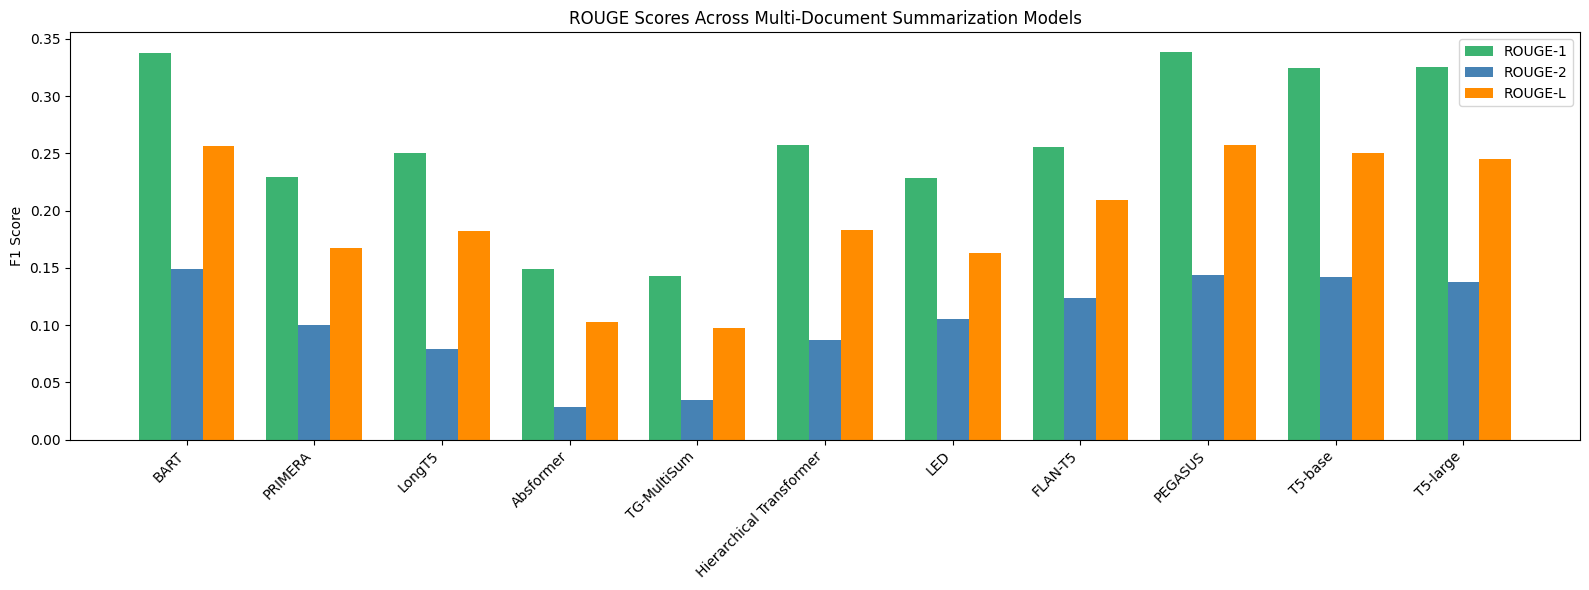

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = [
    "BART", "PRIMERA", "LongT5", "Absformer", "TG-MultiSum",
    "Hierarchical Transformer", "LED", "FLAN-T5", "PEGASUS", "T5-base", "T5-large"
]

# ROUGE scores
rouge1 = [
    0.33748190078811446, 0.22958042470942136, 0.2500854751057612,
    0.1486446877783657, 0.14250656599059133, 0.257663446183102,
    0.22824788709567687, 0.25544370229249247, 0.3387928750952682,
    0.32414105709301666, 0.32582473500051506
]

rouge2 = [
    0.14862936652480413, 0.10046471719506074, 0.07872284396267817,
    0.028765062351581654, 0.03446091487468901, 0.08729911144210234,
    0.10504618191005166, 0.12406966545809209, 0.14381267861819114,
    0.14166798764798125, 0.137541875625957
]

rougeL = [
    0.2568165126333406, 0.167506873160233, 0.18241967088598351,
    0.1024993997121359, 0.09772445567410268, 0.1826776594984139,
    0.16308070381007295, 0.20943925923893508, 0.2577028595412305,
    0.25059260018628876, 0.24530768620587384
]

# Bar positions
x = np.arange(len(models))
width = 0.25

# Plot
plt.figure(figsize=(16, 6))
plt.bar(x - width, rouge1, width, label='ROUGE-1', color='mediumseagreen')
plt.bar(x, rouge2, width, label='ROUGE-2', color='steelblue')
plt.bar(x + width, rougeL, width, label='ROUGE-L', color='darkorange')

plt.xticks(x, models, rotation=45, ha='right')
plt.ylabel("F1 Score")
plt.title("ROUGE Scores Across Multi-Document Summarization Models")
plt.legend()
plt.tight_layout()
plt.show()

 ROUGE Score Reporting and Comparison Table

In [ ]:
import pandas as pd

data = {
    "Model": [
        "BART", "PRIMERA", "LongT5", "Absformer", "TG-MultiSum",
        "Hierarchical Transformer", "LED", "FLAN-T5", "PEGASUS", "T5-base", "T5-large"
    ],
    "ROUGE-1": [
        0.337, 0.229, 0.250, 0.149, 0.143, 0.258, 0.228, 0.255, 0.339, 0.324, 0.326
    ],
    "ROUGE-2": [
        0.149, 0.100, 0.079, 0.029, 0.034, 0.087, 0.105, 0.124, 0.144, 0.142, 0.138
    ],
    "ROUGE-L": [
        0.257, 0.168, 0.182, 0.102, 0.098, 0.183, 0.163, 0.209, 0.258, 0.251, 0.245
    ]
}

df = pd.DataFrame(data)
df.to_csv("rouge_comparison_table.csv", index=False)
print(df)

                       Model  ROUGE-1  ROUGE-2  ROUGE-L
0                       BART    0.337    0.149    0.257
1                    PRIMERA    0.229    0.100    0.168
2                     LongT5    0.250    0.079    0.182
3                  Absformer    0.149    0.029    0.102
4                TG-MultiSum    0.143    0.034    0.098
5   Hierarchical Transformer    0.258    0.087    0.183
6                        LED    0.228    0.105    0.163
7                    FLAN-T5    0.255    0.124    0.209
8                    PEGASUS    0.339    0.144    0.258
9                    T5-base    0.324    0.142    0.251
10                  T5-large    0.326    0.138    0.245


## Conclusion

This project demonstrates the application of text summarization using a standard dataset.
Future improvements may include using more advanced transformer-based models and fine-tuning hyperparameters.
